Cell 1 — Setup and load everything:

In [1]:
import numpy as np
import joblib
import torch
import gc
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, auc, confusion_matrix,
    accuracy_score, f1_score,
    precision_score, recall_score
)

FEAT_DIR   = 'D:/DDI Project/data/features/'
PLOTS_DIR  = 'D:/DDI Project/plots/'
MODEL_XGB  = 'D:/DDI Project/model.pkl'
MODEL_NN   = 'D:/DDI Project/model_nn.pt'

os.makedirs(PLOTS_DIR, exist_ok=True)

# Load feature matrix — stays on disk via mmap
X = np.load(FEAT_DIR + 'X.npy', mmap_mode='r')
y = np.load(FEAT_DIR + 'y.npy', mmap_mode='r')

# Load saved test indices — same split used during training
idx_te = np.load(FEAT_DIR + 'idx_test.npy')

# Build balanced test sample — equal positives and negatives
rng    = np.random.default_rng(42)
pos_te = idx_te[y[idx_te] == 1]
neg_te = idx_te[y[idx_te] == 0]
n_test = min(len(pos_te), len(neg_te))

sample_te = np.concatenate([
    rng.choice(pos_te, size=n_test, replace=False),
    rng.choice(neg_te, size=n_test, replace=False)
])
rng.shuffle(sample_te)

X_test = np.array(X[sample_te], dtype=np.float32)
y_test = np.array(y[sample_te])

print(f"Test set size : {X_test.shape}")
print(f"Positives     : {y_test.sum():,}")
print(f"Negatives     : {(y_test==0).sum():,}")
print(f"RAM used      : ~{X_test.nbytes/1024**2:.0f} MB")
print("Cell 1 done")

Test set size : (26712, 8193)
Positives     : 13,356
Negatives     : 13,356
RAM used      : ~835 MB
Cell 1 done


Cell 2 — Get predictions from all classical models:

In [2]:
# Load XGBoost (best classical model saved from 03_train_classical)
xgb_model = joblib.load(MODEL_XGB)
print(f"XGBoost loaded — expects {xgb_model.n_features_in_} features")

# XGBoost predictions
pred_xgb = xgb_model.predict(X_test)
prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n--- XGBoost (Test Set) ---")
print(classification_report(y_test, pred_xgb))
print(f"AUROC: {roc_auc_score(y_test, prob_xgb):.4f}")

XGBoost loaded — expects 8193 features


d:\DDI Project\ddienv\Lib\site-packages\xgboost\core.py:751: UserWarning: [18:38:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



--- XGBoost (Test Set) ---
              precision    recall  f1-score   support

           0       0.65      0.72      0.68     13356
           1       0.69      0.62      0.65     13356

    accuracy                           0.67     26712
   macro avg       0.67      0.67      0.67     26712
weighted avg       0.67      0.67      0.67     26712

AUROC: 0.7374


Cell 3 — Get predictions from the neural network:

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

# Redefine the same architecture — must match what was saved
class DDINet(nn.Module):
    def __init__(self, input_dim=8193):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

# Load saved weights
nn_model = DDINet(input_dim=8193).to(device)
nn_model.load_state_dict(torch.load(MODEL_NN, map_location=device))
nn_model.eval()
print("Neural network loaded")

# Run predictions in batches
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
test_loader   = DataLoader(X_test_tensor, batch_size=2048, shuffle=False)

all_probs = []
with torch.no_grad():
    for batch in test_loader:
        batch  = batch.to(device)
        probs  = nn_model(batch).cpu().numpy()
        all_probs.extend(probs.tolist())

prob_nn = np.array(all_probs)
pred_nn = (prob_nn >= 0.5).astype(int)

print("\n--- Neural Network (Test Set) ---")
print(classification_report(y_test, pred_nn))
print(f"AUROC: {roc_auc_score(y_test, prob_nn):.4f}")

Using: cuda


C:\Users\sharm\AppData\Local\Temp\ipykernel_7628\1213400687.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nn_model.load_state_dict(torch.load(MODEL_NN, map_location=d

Neural network loaded

--- Neural Network (Test Set) ---
              precision    recall  f1-score   support

           0       0.68      0.68      0.68     13356
           1       0.68      0.69      0.68     13356

    accuracy                           0.68     26712
   macro avg       0.68      0.68      0.68     26712
weighted avg       0.68      0.68      0.68     26712

AUROC: 0.7527


Cell 4 — Full metrics comparison table:

In [4]:
def get_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : f"{accuracy_score(y_true, y_pred)*100:.1f}%",
        'Precision': f"{precision_score(y_true, y_pred)*100:.1f}%",
        'Recall'   : f"{recall_score(y_true, y_pred)*100:.1f}%",
        'F1'       : round(f1_score(y_true, y_pred),        3),
        'AUROC'    : round(roc_auc_score(y_true, y_prob),   3),
    }

results = pd.DataFrame([
    get_metrics('XGBoost',        y_test, pred_xgb, prob_xgb),
    get_metrics('Neural Network', y_test, pred_nn,  prob_nn),
])

print("--- Final Test Set Results ---")
print(results.to_string(index=False))

# Save as CSV for reference
results.to_csv(PLOTS_DIR + 'final_metrics.csv', index=False)
print("\nSaved: plots/final_metrics.csv")

--- Final Test Set Results ---
         Model Accuracy Precision Recall    F1  AUROC
       XGBoost    66.9%     68.7%  62.2% 0.653  0.737
Neural Network    68.4%     68.3%  68.6% 0.684  0.753

Saved: plots/final_metrics.csv


Cell 5 — ROC curves for both models on one chart:

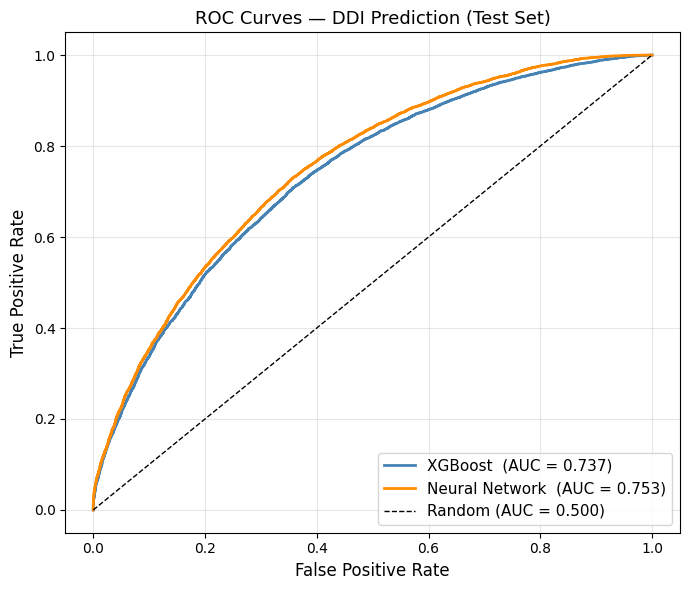

Saved: plots/roc_curves.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

models_to_plot = [
    ('XGBoost',        prob_xgb, 'steelblue'),
    ('Neural Network', prob_nn,  'darkorange'),
]

for name, prob, color in models_to_plot:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name}  (AUC = {roc_auc:.3f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — DDI Prediction (Test Set)', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR + 'roc_curves.png', dpi=150)
plt.show()
print("Saved: plots/roc_curves.png")

Cell 6 — Confusion matrices for both models side by side:

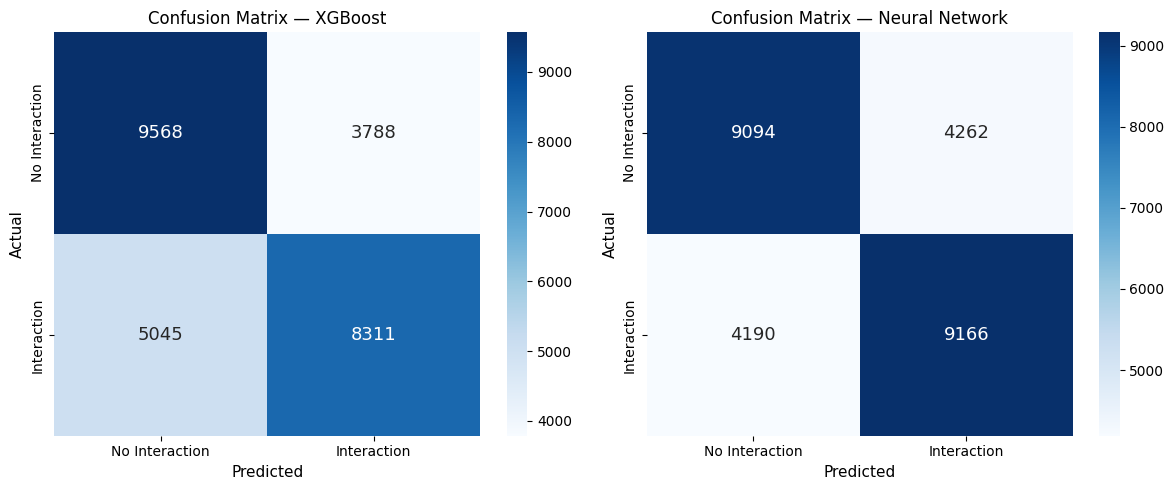

Saved: plots/confusion_matrices.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_results = [
    ('XGBoost',        pred_xgb),
    ('Neural Network', pred_nn),
]

for ax, (name, pred) in zip(axes, model_results):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No Interaction', 'Interaction'],
        yticklabels=['No Interaction', 'Interaction'],
        annot_kws={"size": 13}
    )
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual',    fontsize=11)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12)

plt.tight_layout()
plt.savefig(PLOTS_DIR + 'confusion_matrices.png', dpi=150)
plt.show()
print("Saved: plots/confusion_matrices.png")

Cell 7 — Feature importance (XGBoost):

Cosine similarity global rank : 2805 out of 8,193


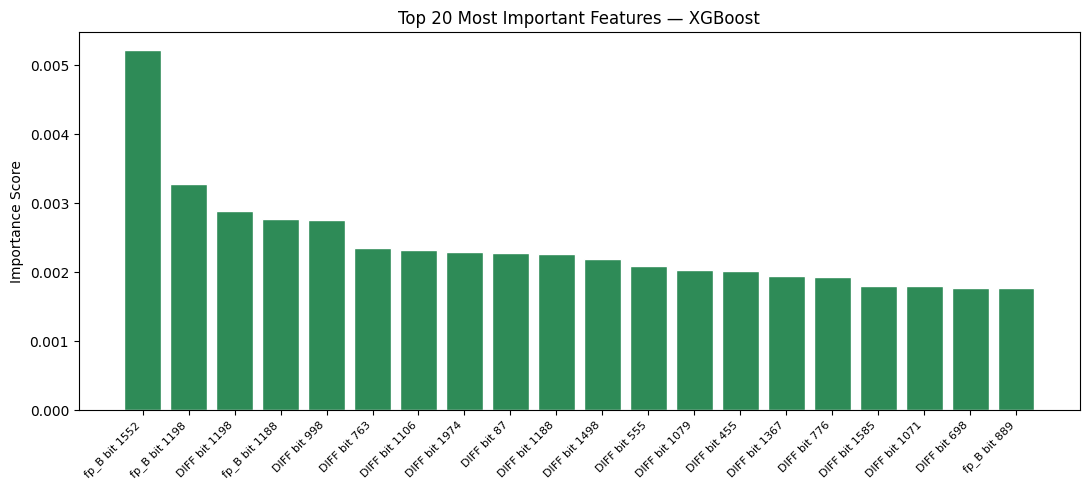

Saved: plots/feature_importance.png


In [7]:
imp     = xgb_model.feature_importances_
top_idx = np.argsort(imp)[::-1][:20]

# Label each feature by which block it belongs to
def get_feature_label(i):
    if i < 2048:
        return f"fp_A bit {i}"
    elif i < 4096:
        return f"fp_B bit {i-2048}"
    elif i < 6144:
        return f"AND bit {i-4096}"
    elif i < 8192:
        return f"DIFF bit {i-6144}"
    else:
        return "Cosine Similarity"

labels = [get_feature_label(i) for i in top_idx]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(20), imp[top_idx], color='seagreen', edgecolor='white')
ax.set_xticks(range(20))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Importance Score')
ax.set_title('Top 20 Most Important Features — XGBoost')

# Highlight if cosine similarity is in top 20
cosine_rank = np.where(np.argsort(imp)[::-1] == 8192)[0][0] + 1
print(f"Cosine similarity global rank : {cosine_rank} out of 8,193")

plt.tight_layout()
plt.savefig(PLOTS_DIR + 'feature_importance.png', dpi=150)
plt.show()
print("Saved: plots/feature_importance.png")

Cell 8 — Precision-Recall curves:

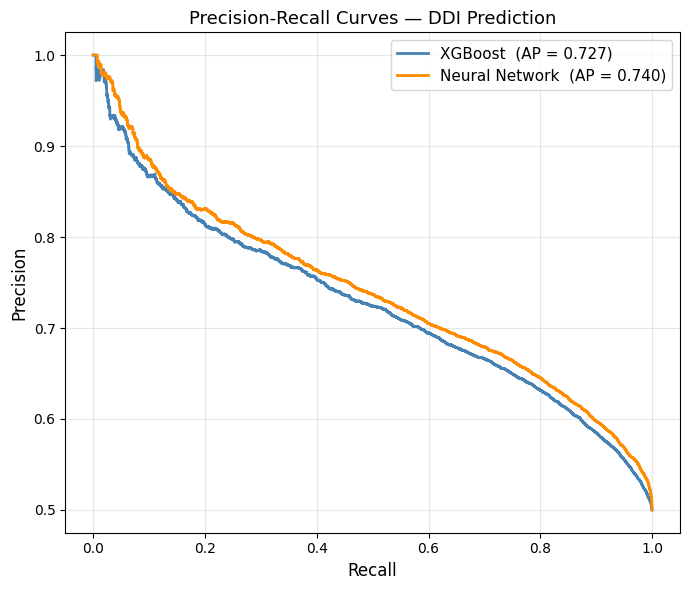

Saved: plots/precision_recall.png


In [8]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(7, 6))

pr_models = [
    ('XGBoost',        prob_xgb, 'steelblue'),
    ('Neural Network', prob_nn,  'darkorange'),
]

for name, prob, color in pr_models:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(recall, precision, color=color, lw=2,
            label=f'{name}  (AP = {ap:.3f})')

ax.set_xlabel('Recall',    fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — DDI Prediction', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR + 'precision_recall.png', dpi=150)
plt.show()
print("Saved: plots/precision_recall.png")

Cell 9 — Final summary printout:

In [9]:
print("=" * 55)
print("  FINAL TEST SET RESULTS SUMMARY")
print("=" * 55)

for name, pred, prob in [
    ('XGBoost',        pred_xgb, prob_xgb),
    ('Neural Network', pred_nn,  prob_nn),
]:
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    aurc = roc_auc_score(y_test, prob)

    print(f"\n  {name}")
    print(f"  Accuracy  : {acc*100:.1f}%")
    print(f"  Precision : {prec*100:.1f}%")
    print(f"  Recall    : {rec*100:.1f}%")
    print(f"  F1 Score  : {f1:.3f}")
    print(f"  AUROC     : {aurc:.3f}")

print()
print(f"  Cosine similarity feature rank : {cosine_rank} / 8,193")
print()
print("  Plots saved:")
print("    roc_curves.png          → use as Figure 3 in paper")
print("    confusion_matrices.png  → use as Figure 4 in paper")
print("    feature_importance.png  → use as Figure 5 in paper")
print("    precision_recall.png    → use as Figure 6 in paper")
print()
print("  Next: run app.py for the Gradio demo")
print("=" * 55)

# Free memory
del xgb_model
nn_model.cpu()
del nn_model
gc.collect()
torch.cuda.empty_cache()
print("\nRAM and GPU memory freed")

  FINAL TEST SET RESULTS SUMMARY

  XGBoost
  Accuracy  : 66.9%
  Precision : 68.7%
  Recall    : 62.2%
  F1 Score  : 0.653
  AUROC     : 0.737

  Neural Network
  Accuracy  : 68.4%
  Precision : 68.3%
  Recall    : 68.6%
  F1 Score  : 0.684
  AUROC     : 0.753

  Cosine similarity feature rank : 2805 / 8,193

  Plots saved:
    roc_curves.png          → use as Figure 3 in paper
    confusion_matrices.png  → use as Figure 4 in paper
    feature_importance.png  → use as Figure 5 in paper
    precision_recall.png    → use as Figure 6 in paper

  Next: run app.py for the Gradio demo

RAM and GPU memory freed
